# AegisSec-FedOps

## End-to-End Evidence, Prediction, SSVC and Human Review

This notebook demonstrates one controlled vertical slice from
component evidence to an auditable policy decision.

**Development boundary**

- SSVC remains authoritative.
- Machine learning remains advisory-only.
- FIRST EPSS is the current near-term forecast lane.
- The custom model classifies current CISA KEV membership.
- Final disposition is not authorized.
- Production readiness remains blocked.

In [1]:
from pathlib import Path
import sys
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.presentation_demo.master_vertical_slice import (
    load_master_vertical_slice,
)
from src.presentation_demo.xai_analysis import (
    load_xai_bundle,
)

master = load_master_vertical_slice()
xai = load_xai_bundle()

DB_PATH = (
    ROOT
    / "data"
    / "processed"
    / "presentation_demo"
    / "aegissec_presentation_risk_mart.sqlite"
)

print("Master vertical slice : PASS")
print("XAI evidence          : PASS")
print("SQLite risk mart      :", DB_PATH.is_file())

Master vertical slice : PASS
XAI evidence          : PASS
SQLite risk mart      : True


## 1. The problem

Vulnerability teams do not only need another severity score.
They need a defensible answer to several different questions:

1. What component is present?
2. Is the exact version affected?
3. Is exploitation already confirmed?
4. Could exploitation occur soon?
5. What is the mission and human impact?
6. What action should the stakeholder take?
7. What still requires human authority?

In [2]:
display(
    master["claim_boundary"]
)

,question,mechanism,authority
0,Is the component present?,Extraction and identity confidence,EVIDENCE
1,Is this exact version affected?,Deterministic version-range matching,AFFECTEDNESS_ENGINE
2,Is exploitation already confirmed?,CISA KEV and trusted intelligence,CONFIRMED_THREAT_EVIDENCE
3,Could exploitation occur soon?,FIRST EPSS 30-day forecast,ADVISORY_FORECAST
4,What does the current custom model predict?,Current CISA KEV membership,ADVISORY_CLASSIFIER
5,What operational action is required?,Governed SSVC plus human review,POLICY_AND_HUMAN


## 2. End-to-end architecture

```text
SBOM / dependencies / screenshot / API
                  ↓
Validation and Trust
schema, authorization, provenance, freshness, integrity
                  ↓
Component extraction and identity confidence
                  ↓
PURL / CPE / alias / version normalization
                  ↓
OSV / NVD / vendor / CISA KEV / FIRST EPSS
                  ↓
Deterministic affectedness
                  ↓
Governed decision-feature envelope
             ↙                         ↘
      SSVC policy engine          Predictive advisory
             ↘                         ↙
        Agreement, conflict and abstention
                  ↓
        Human review and audit record
```

## 3. Controlled portfolio and live risk mart

The presentation inventory contains 16 controlled components
across healthcare, education, public administration and
defence logistics.

In [3]:
with sqlite3.connect(DB_PATH) as connection:
    priority_queue = pd.read_sql_query(
        "SELECT * FROM v_top_priority_queue LIMIT 20",
        connection,
    )

    sector_summary = pd.read_sql_query(
        "SELECT * FROM v_sector_summary",
        connection,
    )

display(priority_queue)
display(sector_summary)

,component_id,sector,ecosystem,target,criticality,vulnerability_count,kev_count,max_epss,source_signal,analytics_signal,attention_score
0,AEG-CMP-0001,HEALTHCARE,Maven,org.apache.logging.log4j:log4j-core@2.14.1,CRITICAL,7,2,0.99999,IMMEDIATE_REVIEW,IMMEDIATE_REVIEW,100.00
1,AEG-CMP-0006,EDUCATION,PyPI,Pillow@8.2.0,MEDIUM,36,1,0.99735,PRIORITY_REVIEW,PRIORITY_REVIEW,84.85
2,AEG-CMP-0004,PUBLIC_ADMINISTRATION,Maven,org.apache.commons:commons-text@1.9,HIGH,1,0,0.99931,PRIORITY_REVIEW,PRIORITY_REVIEW,69.96
3,AEG-CMP-0005,EDUCATION,PyPI,Django@2.2.0,HIGH,65,0,0.65336,PRIORITY_REVIEW,SCHEDULED_REVIEW,50.93
4,AEG-CMP-0015,HEALTHCARE,NuGet,Newtonsoft.Json@12.0.1,HIGH,1,0,0.32908,SCHEDULED_REVIEW,MONITOR,33.10
5,AEG-CMP-0002,HEALTHCARE,Maven,com.fasterxml.jackson.core:jackson-databind@2.9.8,HIGH,55,0,0.26587,SCHEDULED_REVIEW,MONITOR,29.62
6,AEG-CMP-0009,PUBLIC_ADMINISTRATION,npm,lodash@4.17.15,MEDIUM,6,0,0.22410,SCHEDULED_REVIEW,MONITOR,22.33
7,AEG-CMP-0011,HEALTHCARE,npm,axios@0.21.1,HIGH,22,0,0.08515,MONITOR,MONITOR,19.68
8,AEG-CMP-0008,DEFENCE_LOGISTICS,PyPI,PyYAML@5.3.1,CRITICAL,2,0,0.05984,MONITOR,MONITOR,23.29
9,AEG-CMP-0010,EDUCATION,npm,minimist@0.0.8,MEDIUM,2,0,0.04581,MONITOR,MONITOR,7.52


,sector,components,vulnerable_components,components_with_kev,vulnerability_matches,maximum_epss,average_attention_score
0,HEALTHCARE,4,4,1,85,0.99999,45.60
1,EDUCATION,4,3,1,103,0.99735,38.32
2,PUBLIC_ADMINISTRATION,4,4,0,16,0.99931,36.22
3,DEFENCE_LOGISTICS,4,4,0,30,0.05984,21.69


## 4. Screenshot and low-trust input workflow

A screenshot is an observation, not an authoritative SBOM.

The system may extract a candidate package and version, but
ambiguous identity remains **UNKNOWN** and blocks automated
disposition.

In [4]:
display(
    master["screenshot_policy"]
)

,stage,control,behavior
0,SCREENSHOT_VALIDATION,FILE_SAFETY_AND_AUTHORIZATION,Reject unsafe or unauthorized uploads.
1,VISUAL_EXTRACTION,PACKAGE_VERSION_CONFIDENCE,"Produce candidates, never silent certainty."
2,IDENTITY_CONFIRMATION,USER_CONFIRMATION_GATE,Require confirmation for ambiguous identity or...
3,NORMALIZATION,PURL_CPE_ALIAS_RESOLUTION,Unresolved identity remains UNKNOWN.
4,AFFECTEDNESS,EXACT_VERSION_RANGE_MATCH,Do not ask ML to guess deterministic affectedn...
5,FORECAST,FIRST_EPSS_30_DAY_PROBABILITY,Expose forecast as advisory threat evidence.
6,ACTION,SSVC_AND_HUMAN_REVIEW,No automated final disposition.


## 5. Governed artifact chain

The Log4Shell vertical slice reads the actual earlier milestone
artifacts:

- affectedness adjudication
- decision-feature envelope
- official SSVC decision

The notebook does not recreate these decisions.

In [5]:
artifact_chain = pd.DataFrame(
    [
        {
            "Stage": "Affectedness",
            "Artifact": master["paths"]["affectedness"],
        },
        {
            "Stage": "Decision features",
            "Artifact": master["paths"]["decision_features"],
        },
        {
            "Stage": "SSVC decision",
            "Artifact": master["paths"]["ssvc"],
        },
        {
            "Stage": "Model report",
            "Artifact": master["paths"]["model_report"],
        },
        {
            "Stage": "Predictions",
            "Artifact": master["paths"]["predictions"],
        },
    ]
)

display(artifact_chain)

,Stage,Artifact
0,Affectedness,/home/jovyan/vault/aegissec-fedops/data/proces...
1,Decision features,/home/jovyan/vault/aegissec-fedops/data/proces...
2,SSVC decision,/home/jovyan/vault/aegissec-fedops/data/proces...
3,Model report,/home/jovyan/vault/aegissec-fedops/data/proces...
4,Predictions,/home/jovyan/vault/aegissec-fedops/data/proces...


## 6. Deterministic affectedness

Whether a package version falls inside a vulnerable range is an
evidence and version-semantics question. It should not be guessed
by the machine-learning model.

In [6]:
affectedness_flat = (
    pd.json_normalize(
        [master["affectedness"]],
        sep=".",
    )
    .transpose()
    .reset_index()
)

affectedness_flat.columns = [
    "Affectedness field",
    "Value",
]

display(
    affectedness_flat.head(60)
)

,Affectedness field,Value
0,conflicts,[]
1,generated_at,2026-07-15T14:09:04+00:00
2,quality_gates,"[{'expected': 4, 'gate_id': 'M12C-INPUT-REFERE..."
3,report_id,AEG-AFA-9E7D8F8A03A6A1EC07A6CC0A
4,schema_version,1.0.0
5,adjudication.closure_prohibited,True
6,adjudication.confidence,0.9794
7,adjudication.determination_basis,canonical_official_intelligence_plus_component...
8,adjudication.human_review_required,True
9,adjudication.reason_codes,"[PACKAGE_IDENTITY_MATCHED, COMPONENT_VERSION_I..."


## 7. Governed decision-feature envelope

The feature envelope binds technical, threat, exposure, mission,
human-impact and trust evidence into a decision-neutral contract.

In [7]:
feature_flat = (
    pd.json_normalize(
        [master["feature_envelope"]],
        sep=".",
    )
    .transpose()
    .reset_index()
)

feature_flat.columns = [
    "Feature field",
    "Value",
]

display(
    feature_flat.head(80)
)

,Feature field,Value
0,envelope_id,AEG-DFE-AA60735B0E2C053C1B002C64
1,generated_at,2026-07-15T14:09:04+00:00
2,provenance,[{'extraction_method': 'deterministic_mapping'...
3,quality_gates,"[{'expected': 5, 'gate_id': 'M12D-INPUT-REFERE..."
4,schema_version,1.0.0
...,...,...
75,features.exposure_and_reachability.exposure_co...,0.95
76,features.exposure_and_reachability.externally_...,True
77,features.exposure_and_reachability.internet_ac...,True
78,features.exposure_and_reachability.network_zone,dmz


## 8. SSVC decision tree

The implemented deployer policy resolves:

- exploitation
- system exposure
- automatable exploitation
- safety impact
- mission impact
- human impact

The official vector selects a pinned decision-table row and
stakeholder outcome.

In [8]:
summary = master["summary"]

display(
    master["decision_points"]
)

display(
    pd.DataFrame(
        [
            {
                "Decision ID":
                    summary["decision_id"],
                "CVE":
                    summary["cve_id"],
                "SSVC vector":
                    summary["vector"],
                "Matched table row":
                    summary["matched_row"],
                "Official outcome":
                    summary["outcome_name"],
                "Human review":
                    summary[
                        "human_review_required"
                    ],
                "Final disposition":
                    summary[
                        "final_disposition_status"
                    ],
                "Production readiness":
                    summary[
                        "production_readiness"
                    ],
            }
        ]
    )
)

,decision_point,status,key,name,mapping_rule_id,reason_codes
0,automatable,RESOLVED,Y,yes,AUTOMATABLE_EXPLICIT_YES,SSVC_AUTOMATABLE_YES
1,exploitation,RESOLVED,A,active,EXPLOITATION_ACTIVE_PRECEDENCE,SSVC_EXPLOITATION_ACTIVE
2,human_impact,RESOLVED,M,medium,HUMAN_IMPACT_TABLE_ROW_6,SSVC_HUMAN_IMPACT_DERIVED
3,mission_impact,RESOLVED,MEF,mission_essential_failure,MISSION_IMPACT_ESSENTIAL_SEVERE,SSVC_MISSION_IMPACT_MAPPED
4,safety_impact,RESOLVED,M,marginal,SAFETY_IMPACT_MAX_DIMENSION,SSVC_SAFETY_IMPACT_MAPPED
5,system_exposure,RESOLVED,O,open,EXPOSURE_OPEN_ANY_ACCESSIBILITY,SSVC_EXPOSURE_OPEN


,Decision ID,CVE,SSVC vector,Matched table row,Official outcome,Human review,Final disposition,Production readiness
0,AEG-SSVC-72AC3113B91B9A98AF9285D1,CVE-2021-44228,A/O/Y/M,69,OUT_OF_CYCLE,True,NOT_AUTHORIZED,BLOCKED


## 9. SSVC quality gates and provenance

A decision is accepted only after contract, mapping,
determinism, integrity and governance gates pass.

In [9]:
display(
    master["quality_gates"]
)

display(
    master["provenance"]
)

assert summary["stage_gate"] == "PASS"
assert (
    summary["production_readiness"]
    == "BLOCKED"
)
assert (
    summary["final_disposition_status"]
    == "NOT_AUTHORIZED"
)

print("SSVC assurance: PASS")

,expected,gate_id,metric,observed,pass,reason_codes
0,AEGIS-DECISION-FEATURE-CONTRACT:1.0.0,M12E-CONTRACT,upstream_contract,AEGIS-DECISION-FEATURE-CONTRACT:1.0.0,True,[SSVC_INPUT_CONTRACT_VERIFIED]
1,True,M12E-INTEGRITY,input_canonical_integrity,True,True,[SSVC_INPUT_INTEGRITY_VERIFIED]
2,PASS,M12E-UPSTREAM-STAGE,upstream_stage_gate,PASS,True,[SSVC_INPUT_CONTRACT_VERIFIED]
3,0,M12E-CONFLICTS,blocking_conflict_count,0,True,[SSVC_NO_BLOCKING_CONFLICTS]
4,6,M12E-MANDATORY-POINTS,resolved_decision_point_count,6,True,[SSVC_MANDATORY_POINTS_RESOLVED]
5,0..15,M12E-HUMAN-IMPACT,human_impact_table_row,6,True,[SSVC_HUMAN_IMPACT_DERIVED]
6,0..71,M12E-DEPLOYER-ROW,deployer_table_row,69,True,[SSVC_OFFICIAL_ROW_MATCHED]
7,5,M12E-POLICY-HASHES,policy_hash_count,5,True,[SSVC_POLICY_HASHES_VERIFIED]
8,True,M12E-REASON-REGISTRY,closed_reason_registry,True,True,[SSVC_REASON_REGISTRY_VERIFIED]
9,0,M12E-SEPARATION,unauthorized_downstream_outputs,0,True,"[SSVC_FEDERAL_OVERLAY_NOT_APPLIED, SSVC_ML_ADV..."


,decision_path,input_envelope_id,input_sha256,mapping_rule_id,source_feature_paths
0,/mapping/decision_points/exploitation,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,EXPLOITATION_ACTIVE_PRECEDENCE,[/features/exploitation/known_exploitation_sta...
1,/mapping/decision_points/system_exposure,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,EXPOSURE_OPEN_ANY_ACCESSIBILITY,[/features/exposure_and_reachability/internet_...
2,/mapping/decision_points/automatable,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,AUTOMATABLE_EXPLICIT_YES,[/features/exploitation/ssvc_source_assertion/...
3,/mapping/decision_points/safety_impact,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,SAFETY_IMPACT_MAX_DIMENSION,[/features/mission_and_sector_impact/dimension...
4,/mapping/decision_points/mission_impact,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,MISSION_IMPACT_ESSENTIAL_SEVERE,[/features/asset_criticality/mission_essential...
5,/mapping/decision_points/human_impact,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,HUMAN_IMPACT_TABLE_ROW_6,"[/mapping/decision_points/safety_impact/key, /..."
6,/mapping/decision_points/human_impact/key,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,HUMAN_IMPACT_TABLE_ROW_6,"[/mapping/decision_points/safety_impact/key, /..."
7,/official_ssvc_decision/outcome,AEG-DFE-AA60735B0E2C053C1B002C64,033d2435e709be5af76e124d77c225bd1125d5da47864b...,DEPLOYER_TABLE_ROW_69,"[/mapping/decision_points/exploitation/key, /m..."


SSVC assurance: PASS


## 10. Prediction and SSVC are different

A high forecast does not prove active exploitation.
Confirmed exploitation evidence must not be rewritten by a
probabilistic model.

In [10]:
display(
    master["agreement_matrix"]
)

,affectedness,confirmed_exploitation,forecast,policy_behavior,human_review,reason
0,NOT_AFFECTED,ANY,ANY,NO_ASSET_REMEDIATION,ONLY_FOR_IDENTITY_OR_EVIDENCE_CONFLICT,A global CVE does not affect this exact asset ...
1,AFFECTED,ACTIVE_OR_KEV,ANY,USE_ACTIVE_EXPLOITATION_BRANCH,REQUIRED_BY_POLICY,Confirmed exploitation supersedes probabilisti...
2,AFFECTED,NOT_OBSERVED,HIGH,DO_NOT_MARK_ACTIVE,ESCALATE_PREDICTIVE_REVIEW,A high forecast raises concern but does not pr...
3,UNKNOWN,ANY,ANY,FAIL_CLOSED,MANDATORY,Unknown identity or version evidence blocks au...
4,AFFECTED,NOT_OBSERVED,LOW,CONTEXT_DRIVEN,MISSION_AND_HUMAN_IMPACT_DEPENDENT,Low forecast does not remove mission or safety...


## 11. Current real-data model

The custom model currently classifies **current CISA KEV
membership**. It is useful for advisory triage research, but
it is not a future-exploitation forecast.

In [11]:
model_report = master["model_report"]

metrics = model_report[
    "test_metrics"
]

model_summary = pd.DataFrame(
    [
        {
            "Metric":
                "Winning model",
            "Value":
                model_report[
                    "winner"
                ][
                    "candidate_name"
                ],
        },
        {
            "Metric":
                "Label",
            "Value":
                model_report[
                    "governance"
                ][
                    "label_definition"
                ],
        },
        {
            "Metric":
                "Accuracy",
            "Value":
                metrics["accuracy"],
        },
        {
            "Metric":
                "Balanced accuracy",
            "Value":
                metrics[
                    "balanced_accuracy"
                ],
        },
        {
            "Metric":
                "Precision",
            "Value":
                metrics["precision"],
        },
        {
            "Metric":
                "Recall",
            "Value":
                metrics["recall"],
        },
        {
            "Metric":
                "F1",
            "Value":
                metrics["f1"],
        },
        {
            "Metric":
                "ROC-AUC",
            "Value":
                metrics["roc_auc"],
        },
        {
            "Metric":
                "PR-AUC",
            "Value":
                metrics["pr_auc"],
        },
    ]
)

display(model_summary)

,Metric,Value
0,Winning model,logistic_c_10
1,Label,CURRENT_CISA_KEV_MEMBERSHIP
2,Accuracy,0.972489
3,Balanced accuracy,0.866686
4,Precision,0.119389
5,Recall,0.759878
6,F1,0.206356
7,ROC-AUC,0.96671
8,PR-AUC,0.382801


## 12. Can the model score be improved?

The operating threshold can improve precision or F1, but the
trade-off is lower recall. This changes the review policy rather
than adding new predictive knowledge.

,policy,threshold,predicted_positive,precision,recall,f1,balanced_accuracy,interpretation
0,CURRENT_HIGH_RECALL,0.844979,2094.0,0.119389,0.759878,0.206356,0.866686,Current development operating point. Higher re...
1,BEST_F1_DEVELOPMENT,0.996716,136.0,0.647059,0.267477,0.378495,0.633394,Best observed F1 on the existing test predicti...
2,MAX_PRECISION_WITH_RECALL_70,0.910431,1540.0,0.150649,0.705167,0.248261,0.843183,Highest observed precision while retaining at ...
3,MAX_RECALL_WITH_PRECISION_25,0.982583,537.0,0.281192,0.458967,0.348730,0.726709,Highest observed recall while maintaining at l...


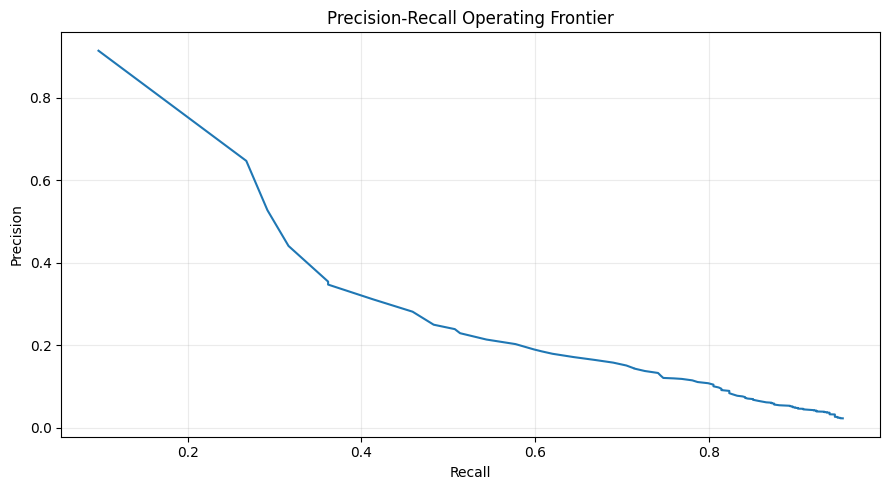

In [12]:
display(
    master["operating_points"]
)

frontier = master[
    "threshold_frontier"
]

plt.figure(figsize=(9, 5))

plt.plot(
    frontier["recall"],
    frontier["precision"],
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Operating Frontier"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. Near-term exploitation forecast

FIRST EPSS is the present 30-day exploitation forecast lane.

A future AegisSec-native forecasting model requires:

- historical features available at time **t**
- exploitation observed during **t+1 to t+30**
- temporal train, validation and test windows
- no post-event leakage
- calibration and drift monitoring
- explicit abstention and human review

In [13]:
forecast_examples = (
    master["predictions"][
        [
            "cve",
            "epss",
            "percentile",
            "is_kev",
            "predicted_probability",
            "prediction",
        ]
    ]
    .sort_values(
        [
            "epss",
            "percentile",
        ],
        ascending=False,
    )
    .head(20)
)

display(forecast_examples)

print(
    "Current near-term forecast lane:",
    summary[
        "near_term_forecast_lane"
    ],
)

print(
    "Future custom forecast:",
    summary[
        "future_custom_forecast"
    ],
)

,cve,epss,percentile,is_kev,predicted_probability,prediction
49370,CVE-2024-21893,0.99999,0.99999,1,0.999997,1
56809,CVE-2024-21887,0.99999,0.99999,1,0.999997,1
14503,CVE-2021-34473,0.99999,0.99998,1,0.999994,1
3297,CVE-2019-19781,0.99999,0.99997,1,0.999989,1
13557,CVE-2023-44487,0.99999,0.99997,1,0.999996,1
1363,CVE-2024-23897,0.99999,0.99995,1,0.999997,1
3540,CVE-2022-29464,0.99999,0.99995,1,0.999995,1
61195,CVE-2018-13379,0.99999,0.99994,1,0.999985,1
17205,CVE-2023-1389,0.99999,0.99992,1,0.999996,1
28097,CVE-2021-21985,0.99999,0.99992,1,0.999994,1


Current near-term forecast lane: FIRST_EPSS_30_DAY_ADVISORY
Future custom forecast: NOT_YET_AUTHORIZED


## 14. Global and local XAI

The Logistic Regression explanation is exact: standardized
feature contributions reconstruct the decision probability.

In [14]:
display(
    xai["coefficients"]
)

display(
    xai["examples"]
)

print(
    "Maximum probability reconstruction error:",
    xai["report"][
        "local_explanation"
    ][
        "maximum_probability_reconstruction_error"
    ],
)

,feature,standardized_coefficient,raw_unit_coefficient,absolute_coefficient,direction,odds_ratio_per_standard_deviation
0,epss_logit,1.467856,0.676014,1.467856,TOWARD_KEV_MEMBERSHIP,4.339920
1,percentile,1.320207,4.358754,1.320207,TOWARD_KEV_MEMBERSHIP,3.744195
2,cve_year,0.849627,0.136952,0.849627,TOWARD_KEV_MEMBERSHIP,2.338773
3,cve_age_years,-0.849627,-0.136952,0.849627,AWAY_FROM_KEV_MEMBERSHIP,0.427575
4,epss_log10,0.186876,0.271334,0.186876,TOWARD_KEV_MEMBERSHIP,1.205478
5,epss,0.170729,0.917583,0.170729,TOWARD_KEV_MEMBERSHIP,1.186169
6,percentile_squared,0.140402,0.429130,0.140402,TOWARD_KEV_MEMBERSHIP,1.150736
7,percentile_ge_0_90,0.107310,0.296594,0.107310,TOWARD_KEV_MEMBERSHIP,1.113279
8,percentile_ge_0_99,-0.105388,-0.513168,0.105388,AWAY_FROM_KEV_MEMBERSHIP,0.899975
9,epss_ge_0_10,-0.083146,-0.275617,0.083146,AWAY_FROM_KEV_MEMBERSHIP,0.920217


,cve,outcome_type,actual_is_kev,prediction,predicted_probability,reconstructed_probability,reconstruction_error,decision_logit,epss,percentile,cve_year,cve_age_years
0,CVE-2024-21887,TRUE_POSITIVE,1,1,0.999997,0.999997,1.110223e-16,12.782665,0.99999,0.99999,2024,2
1,CVE-2024-29826,FALSE_POSITIVE,0,1,0.999927,0.999927,0.000000e+00,9.525649,0.99877,0.99964,2024,2
2,CVE-2023-46748,FALSE_NEGATIVE,1,0,0.844005,0.844005,0.000000e+00,1.688334,0.04468,0.90389,2023,3
3,CVE-1999-1101,TRUE_NEGATIVE,0,0,0.000014,0.000014,0.000000e+00,-11.143670,0.00246,0.15777,1999,27


Maximum probability reconstruction error: 1.1102230246251565e-16


## 15. Weakness analysis

False positives create analyst workload. False negatives show
why the model cannot replace KEV evidence, SSVC or human review.

In [15]:
display(
    xai["slices"]
)

xai_checks = pd.DataFrame(
    [
        {
            "Check": key,
            "Passed": value,
        }
        for key, value in (
            xai["report"][
                "quality_gate"
            ][
                "checks"
            ].items()
        )
    ]
)

display(xai_checks)

assert xai_checks["Passed"].all()

print(
    "Automated XAI assurance: PASS"
)

,slice_dimension,slice_value,rows,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
0,epss_band,0_TO_1_PERCENT,41056,0,0,10,41046,NaN,0.000000,0.000000,1.000000
1,epss_band,1_TO_10_PERCENT,25358,16,409,51,24882,0.037647,0.238806,0.016172,0.761194
2,epss_band,10_TO_50_PERCENT,2612,63,903,17,1629,0.065217,0.787500,0.356635,0.212500
3,epss_band,50_TO_100_PERCENT,873,171,532,1,169,0.243243,0.994186,0.758916,0.005814
4,age_band,AGE_0_TO_2,22938,73,481,27,22357,0.131769,0.730000,0.021061,0.270000
5,age_band,AGE_3_TO_5,15813,80,648,15,15070,0.109890,0.842105,0.041227,0.157895
6,age_band,AGE_6_TO_10,15251,76,595,21,14559,0.113264,0.783505,0.039264,0.216495
7,age_band,AGE_11_TO_20,12726,21,120,14,12571,0.148936,0.600000,0.009456,0.400000
8,age_band,AGE_OVER_20,3171,0,0,2,3169,NaN,0.000000,0.000000,1.000000


,Check,Passed
0,all_four_outcomes_present,True
1,false_negatives_detected,True
2,false_positives_detected,True
3,label_excluded_from_features,True
4,model_advisory_only,True
5,probability_reconstruction_error_below_1e_9,True
6,production_blocked,True
7,ssvc_authority_preserved,True


Automated XAI assurance: PASS


## 16. Human-review record

The human reviewer receives evidence, policy, forecast,
explanations, conflicts and authorization boundaries in one case.

In [16]:
human_review = pd.DataFrame(
    [
        {
            "Case":
                summary["decision_id"],
            "CVE":
                summary["cve_id"],
            "SSVC vector":
                summary["vector"],
            "SSVC outcome":
                summary["outcome_name"],
            "Forecast lane":
                summary[
                    "near_term_forecast_lane"
                ],
            "Custom model":
                summary["model_winner"],
            "Model authority":
                summary[
                    "model_authority"
                ],
            "Human review":
                summary[
                    "human_review_required"
                ],
            "Final disposition":
                summary[
                    "final_disposition_status"
                ],
            "Production":
                summary[
                    "production_readiness"
                ],
        }
    ]
)

display(human_review)

,Case,CVE,SSVC vector,SSVC outcome,Forecast lane,Custom model,Model authority,Human review,Final disposition,Production
0,AEG-SSVC-72AC3113B91B9A98AF9285D1,CVE-2021-44228,A/O/Y/M,OUT_OF_CYCLE,FIRST_EPSS_30_DAY_ADVISORY,logistic_c_10,ADVISORY_ONLY,True,NOT_AUTHORIZED,BLOCKED


## 17. Responsible-AI and assurance evidence

The architecture separates evidence, prediction, policy and
human authority. It also preserves integrity, provenance,
testing, explainability, fail-closed behavior and release gates.

In [17]:
coverage_rows = []

coverage_files = [
    (
        "Full-source coverage",
        ROOT
        / "reports"
        / "presentation"
        / "full_source_coverage_final.json",
    ),
    (
        "XAI-focused coverage",
        ROOT
        / "reports"
        / "presentation"
        / "xai_coverage_final.json",
    ),
]

for label, path in coverage_files:
    if path.is_file():
        document = json.loads(
            path.read_text(
                encoding="utf-8"
            )
        )

        coverage_rows.append(
            {
                "Evidence": label,
                "Result": (
                    str(
                        round(
                            float(
                                document[
                                    "totals"
                                ][
                                    "percent_covered"
                                ]
                            ),
                            2,
                        )
                    )
                    + "%"
                ),
            }
        )

coverage_rows.extend(
    [
        {
            "Evidence":
                "SSVC stage gate",
            "Result":
                summary["stage_gate"],
        },
        {
            "Evidence":
                "Model authority",
            "Result":
                summary[
                    "model_authority"
                ],
        },
        {
            "Evidence":
                "Final disposition",
            "Result":
                summary[
                    "final_disposition_status"
                ],
        },
        {
            "Evidence":
                "Production readiness",
            "Result":
                summary[
                    "production_readiness"
                ],
        },
    ]
)

display(
    pd.DataFrame(
        coverage_rows
    )
)

,Evidence,Result
0,Full-source coverage,80.45%
1,XAI-focused coverage,92.0%
2,SSVC stage gate,PASS
3,Model authority,ADVISORY_ONLY
4,Final disposition,NOT_AUTHORIZED
5,Production readiness,BLOCKED


# Final conclusion

AegisSec-FedOps does not collapse vulnerability management
into one score.

It separates:

1. what is present
2. what is affected
3. what is already exploited
4. what may be exploited soon
5. what the operational impact is
6. what SSVC recommends
7. what still requires human authority

That separation is the foundation of a trustworthy,
auditable and government-oriented system.